# Original Mag1c
In this code the original mag1c is called to create the ground truth.

File size: 125.00 MB
Loading: ../resources/test_tile_512_512_125.hdr
Loaded image shape: (512, 512, 50)
[np.float64(1573.3193359375), np.float64(1580.7620849609375), np.float64(1588.2049560546875), np.float64(1595.646728515625), np.float64(1603.088623046875), np.float64(1610.529541015625), np.float64(1617.970458984375), np.float64(1625.410400390625), np.float64(1632.851318359375), np.float64(1640.290283203125), np.float64(1647.7303466796875), np.float64(1655.16943359375), np.float64(1662.607421875), np.float64(1670.0455322265625), np.float64(1677.483642578125), np.float64(1684.9208984375), np.float64(1692.3580322265625), np.float64(1699.795166015625), np.float64(1707.2314453125), np.float64(1714.666748046875), np.float64(1722.10302734375), np.float64(1729.538330078125), np.float64(1736.97265625), np.float64(1744.4071044921875), np.float64(1751.8414306640625), np.float64(1759.27490234375), np.float64(1766.7083740234375), np.float64(1774.141845703125), np.float64(1781.5743408203125), np.

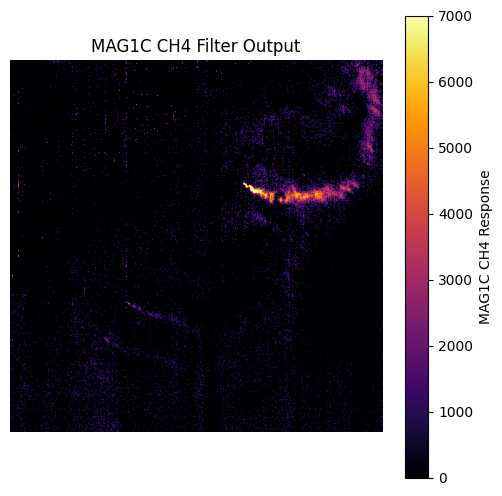

'if __name__ == "__main__":\n    main()'

In [1]:
import spectral as spy
import numpy as np
import os
import subprocess
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import sys
import argparse

def reconstruct_if_needed():
    """Rebuild the split test tile if necessary."""
    output_path = "../resources/test_tile_512_512_125.img"
    split_parts = sorted(
        [f for f in os.listdir('../resources') if f.startswith('test_tile_512_512_125_part')]
    )

    if not os.path.exists(output_path) and split_parts:
        with open(output_path, 'wb') as outfile:
            for part in split_parts:
                with open(os.path.join("../resources/", part), 'rb') as infile:
                    outfile.write(infile.read())
        print(f"✅ Reconstructed {output_path}")

    print(f"File size: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")
    return output_path

def load_hyperspectral_image(hdr_path, channels=None):
    """Load hyperspectral image using Spectral Python (SPy)."""
    print(f"Loading: {hdr_path}")
    img = spy.open_image(hdr_path).load()
    metadata = img.metadata

    wavelengths = metadata.get("wavelength", None)
    if wavelengths:
        wavelengths = np.array([float(w) for w in wavelengths])

    fwhm = metadata.get("fwhm", None)
    if fwhm:
        try:
            fwhm = np.array([float(f) for f in fwhm])
        except ValueError:
            print("⚠️ Invalid FWHM values detected — using default 10.0 nm.")
            fwhm = np.ones_like(wavelengths) * 10.0
    else:
        fwhm = np.ones_like(wavelengths) * 10.0

    if channels:
        img = img[:, :, :channels]
        wavelengths = wavelengths[:channels]
        fwhm = fwhm[:channels]

    print(f"Loaded image shape: {img.shape}")
    return img, wavelengths, fwhm

def compute_mag1c(img, wavelengths, fwhm, name="mag1c_temp", precision="float64"):
    """Run MAG1C on a hyperspectral image."""
    output_metadata = {
        "wavelength units": "nm",
        "wavelength": list(wavelengths),
        "fwhm": list(fwhm),
    }
    print(output_metadata["wavelength"])

    # Save ENVI file for MAG1C
    envi.save_image(
        f"{name}.hdr",
        img,
        shape=img.shape,
        interleave="bil",
        metadata=output_metadata,
        force=True,
    )

    print("Running MAG1C...")
    arg = [
        sys.executable,
        "../benchmark/mag1c_fork/mag1c/mag1c.py",
        name,
        "-o",
        "--use-wavelength-range",
        "300",
        "2600",
        "--save-target-spectrum-centers",
        "--quiet",
        "--sample",
        str(0.01)
    ]
    if precision == "float32":
        arg += ["--single"]

    try:
        output = subprocess.run(arg, capture_output=True, text=True, check=True)
        print("STDOUT:")
        print(output.stdout)
        print("✅ MAG1C finished.")
    except subprocess.CalledProcessError as e:
        print("❌ Error running MAG1C:")
        print(e.stderr)
        return None

    # Load the MAG1C output filter image
    output_hdr = f"{name}_ch4_cmfr.hdr"
    if not os.path.exists(output_hdr):
        print(f"❌ MAG1C output {output_hdr} not found.")
        return None

    ch4_img = spy.open_image(output_hdr).load()
    print(f"Loaded MAG1C CH4 filter image with shape {ch4_img.shape}")
    return ch4_img

def visualize_results(ch4_img):
    """Visualize MAG1C CH4 filter output."""
    print("Visualizing MAG1C CH4 output...")
    plt.figure(figsize=(6, 6))
    plt.imshow(ch4_img, cmap='inferno')  # single band
    plt.colorbar(label="MAG1C CH4 Response")
    plt.title("MAG1C CH4 Filter Output")
    plt.axis("off")
    plt.show()
    

#def main():
reconstruct_if_needed()

parser = argparse.ArgumentParser(description="Run MAG1C on a hyperspectral tile.")
parser.add_argument("--channels", type=int, default=50, help="Number of spectral bands to use.")
parser.add_argument("--hdr-path", type=str, default="../resources/test_tile_512_512_125.hdr",
                    help="Path to the HDR file.")
parser.add_argument("--precision", type=str, default="float64", choices=["float32", "float64"],
                    help="Floating-point precision for computation.")
args, unknown = parser.parse_known_args()

img, wavelengths, fwhm = load_hyperspectral_image(args.hdr_path, args.channels)
img = img.reshape(-1,1,args.channels)
ch4_img = compute_mag1c(img, wavelengths, fwhm, precision=args.precision)
ch4_img = ch4_img.reshape(512,512,-1)[:, :, 3]
print((ch4_img < -1).sum())
ch4_img_vis = np.clip(ch4_img, 0, 7000)
if ch4_img is not None:
    visualize_results(ch4_img_vis)

"""if __name__ == "__main__":
    main()"""


# Mag1c (torch)
In this code only the core Mag1c function are copied and tested that they give same results as ground truth.

(262144, 1, 50)
(262144, 1, 50) before censoring
(262144,)
torch.Size([1, 262142, 31]) torch.Size([31])
torch.float64 torch.float64
torch.Size([1, 262144, 1])
Visualizing MAG1C CH4 output...


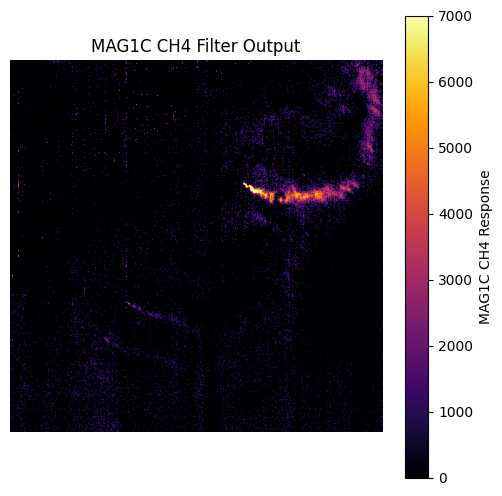

In [2]:
import torch
from typing import Tuple, Optional
NODATA = -9999
def get_censor_mask(x: np.ndarray) -> np.ndarray:
    """Determines the regions of the image that are censored. This assumes that an
    entire 'bar'/sample-direction (in un-geocorrected data) is censored together.

    :param x: Radiance image data to analyze for censored regions.
    :return: Boolean 1D ndarray (corresponding to column/flight direction) with True where censoring is detected.
    """
    print(x.shape, "before censoring")
    is_censored = np.diff(x, axis=0) == 0
    is_censored = np.all(is_censored, axis=(1, 2))
    is_censored = np.logical_or(
        np.logical_or(
            np.concatenate(([0, 0], is_censored[:-1])),
            np.concatenate((is_censored[1:], [0, 0])),
        ),
        np.logical_or(
            np.concatenate(([1], is_censored)), np.concatenate((is_censored, [1]))
        ),
    )
    # Also skip regions that are marked as No Data, value -9999
    is_censored = np.logical_or(
        is_censored, np.any(x == NODATA, axis=(1, 2))
    )  # TODO might want to split this out
    return is_censored

def compute_sampled_filter(rdn_data, sat_mask, spec, indices):
    print(rdn_data.shape, spec.shape)
    print(rdn_data.dtype, spec.dtype)
    rdn_data_sample = rdn_data[:, indices, :]
    sat_mask_sample = sat_mask[:,indices] if sat_mask is not None else None
    mu, Cit, normalizer = acrwl1mf(
        x=rdn_data_sample,
        template=spec,
        num_iter=30,
        albedo_override=False,
        zero_override=False,
        sparse_override=False,
        covariance_update_scaling=1.0,
        alpha=0.0,
        mask=torch.logical_not(sat_mask_sample) if sat_mask_sample is not None else None,
        sample=True,
    )
    mf_out, albedo_out = acrwl1mf_compact(
        x=rdn_data,
        normalizer=normalizer,
        num_iter=3,
        albedo_override=False,
        zero_override=False,
        sparse_override=False,
        mu=mu,
        Cit=Cit,
    )
    return mf_out, albedo_out

@torch.no_grad()
def acrwl1mf(
    x: torch.Tensor,
    template: torch.Tensor,
    num_iter: int,
    albedo_override: bool,
    zero_override: bool,
    sparse_override: bool,
    covariance_update_scaling: float,
    alpha: float,
    mask: Optional[torch.Tensor],
    sample: bool,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Calculate the albedo-corrected reweighted-L1 matched filter on radiance data.

    :param x: Radiance Data to process. See notes below on format.
    :param template: Target spectrum for detection.
    :param num_iter: Number of iterations to run.
    :param albedo_override: Do not calculate or apply albedo correction factor.
    :param zero_override: Do not apply non-negativity constraint on matched filter results.
    :param sparse_override: Do not use sparse regularization in iterations when True.
    :param covariance_update_scaling: scalar value controls contribution of previous filter values in removing target
        signal in covariance and mean updates.
    :param alpha: scalar value to perform diagonal scaling of the covariance matrix
    :param mask: An optional mask to mark where data should contribute to covariance and mean.
    :returns mf, albedo

        x must be 3-dimensional:
        batch (columns or groups of columns) x
        pixels (samples) x
        spectrum (bands)

        Notice that the samples dimension must be shared
        by the batch, so only batches/columns with the same number
        of pixels to process may be combined into a batch.
    """
    # Some constants / arrays to preallocate
    dtype = x.dtype
    device = x.device
    N = x.shape[1]  # number of samples
    if mask is None:
        mask = torch.ones_like(x, dtype=torch.bool)
    mask = torch.squeeze(mask, 0)
    regularizer = torch.zeros(x.shape[0], x.shape[1], 1, dtype=dtype, device=device)
    #modx = x
    modx = x[
        :, mask
    ] # torch.zeros_like(x, dtype=dtype, device=device, layout=torch.strided)
    #template = template.unsqueeze(0).unsqueeze(0)
    scaling = torch.tensor(1e5, dtype=dtype, device=device)
    epsilon = torch.tensor(1e-9, dtype=dtype, device=device)
    covariance_update_scaling = torch.tensor(
        -covariance_update_scaling, dtype=dtype, device=device
    )
    alpha = torch.tensor(alpha, dtype=dtype, device=device)
    # energy = torch.zeros(num_iter + 1, dtype=dtype, device=device)
    # Initialize with normal robust matched filter
    mu = torch.mean(modx, 1, keepdim=True)  # [batch x 1 x spectrum]
    if albedo_override:
        R = torch.ones((x.shape[0], N, 1), dtype=dtype, device=device)
    else:
        R = torch.div(
            torch.bmm(
                x, torch.transpose(mu, 1, 2)
            ),  # [b x p x s] * [b x s x 1] = [b x p x 1]
            torch.bmm(mu, torch.transpose(mu, 1, 2)),
        )  # [b x 1 x s] * [b x s x 1] = [b x 1 x 1]
    target = torch.mul(template, mu)  # [1 x 1 x s] * [b x 1 x s] = [b x 1 x s]
    xmean = modx - mu
    C = (
        torch.bmm(torch.transpose(xmean, 1, 2), xmean) / N
    )  # [b x s x p] * [b x p x s] = [b x s x s]
    C = C.lerp_(
        torch.diag_embed(torch.diagonal(C, dim1=-2, dim2=-1)), alpha
    )  # C = (1-alpha) * S + alpha * diag(S)
    # Cit, _ = torch.gesv(torch.transpose(target, 1, 2), C)  # [b x s x 1] \ [b x s x s] = [b x s x 1]
    # print(np.linalg.eigvals(C.cpu().numpy()))  # check if eigenvalues are positive
    Cit = torch.cholesky_solve(
        torch.transpose(target, 1, 2),
        torch.linalg.cholesky(C, upper=False),
        upper=False,
    )
    normalizer = torch.bmm(target, Cit)  # [b x 1 x s] * [b x s x 1] = [b x 1 x 1]
    mf = torch.div(
        torch.bmm(x - mu, Cit), torch.mul(R, normalizer)
    )  # [b x p x s] * [b x s x 1] = [b x p x 1]
    if not zero_override:
        mf = torch.nn.functional.relu_(mf)  # max(mf, 0)
    # TODO Calculate Energy
    # Reweighted L1 Algorithm
    for i in range(num_iter):
        # Calculate new regularizer weights
        if not sparse_override:  # regularizer pre-defined as zeros.
            regularizer = torch.reciprocal(torch.mul(R, mf + epsilon), out=regularizer)
        # Re-calculate statistics
        modx = torch.add(
            x[:, mask],
            alpha=covariance_update_scaling,
            other=R[:, mask] * mf[:, mask] * target,
            out=modx,
        )
        """modx = torch.add(
            x,
            alpha=covariance_update_scaling,
            other=R * mf * target,
            out=modx,
        )"""
        mu = torch.mean(modx, 1, keepdim=True, out=mu)
        target = torch.mul(template, mu, out=target)
        xmean = torch.add(modx, alpha=-1, other=mu, out=xmean)
        C = torch.div(
            torch.bmm(torch.transpose(xmean, 1, 2), xmean), other=torch.tensor(N), out=C
        )
        C = C.lerp_(torch.diag_embed(torch.diagonal(C, dim1=-2, dim2=-1)), alpha)
        Cit = torch.cholesky_solve(
            torch.transpose(target, 1, 2),
            torch.linalg.cholesky(C, upper=False),
            upper=False,
        )
        # Compute matched filter with regularization
        normalizer = torch.bmm(target, Cit, out=normalizer)
        if torch.sum(torch.lt(normalizer, 1)):
            normalizer = normalizer.clamp_(min=1)
        if num_iter == i+1 and sample:
            return mu, Cit, normalizer
        mf = torch.div(torch.bmm(x - mu, Cit) - regularizer, torch.mul(R, normalizer))
        mf = torch.nn.functional.relu_(mf)
        # TODO energy
    mf = torch.mul(mf, scaling, out=mf)
    return mf, R

@torch.no_grad()
def acrwl1mf_compact(
    x: torch.Tensor,
    normalizer: torch.Tensor,
    num_iter: int,
    albedo_override: bool,
    zero_override: bool,
    sparse_override: bool,
    mu: torch.Tensor,
    Cit: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Calculate the albedo-corrected reweighted-L1 matched filter on radiance data.

    :param x: Radiance Data to process. See notes below on format.
    :param normalizer: Normalizer computed from sample.
    :param num_iter: Number of iterations to run.
    :param albedo_override: Do not calculate or apply albedo correction factor.
    :param zero_override: Do not apply non-negativity constraint on matched filter results.
    :param sparse_override: Do not use sparse regularization in iterations when True.
    :param mu: Band means computed from sample.
    :param Cit: Inverted Covariance matrix computed from sample
    :returns mf, albedo

        x must be 3-dimensional:
        batch (columns or groups of columns) x
        pixels (samples) x
        spectrum (bands)

        Notice that the samples dimension must be shared
        by the batch, so only batches/columns with the same number
        of pixels to process may be combined into a batch.
    """
    # Some constants / arrays to preallocate
    dtype = x.dtype
    device = x.device
    N = x.shape[1]  # number of samples
    regularizer = torch.zeros(x.shape[0], x.shape[1], 1, dtype=dtype, device=device)
    scaling = torch.tensor(1e5, dtype=dtype, device=device)
    epsilon = torch.tensor(1e-9, dtype=dtype, device=device)
    # energy = torch.zeros(num_iter + 1, dtype=dtype, device=device)
    # Initialize with normal robust matched filter
    if albedo_override:
        R = torch.ones((x.shape[0], N, 1), dtype=dtype, device=device)
    else:
        R = torch.div(
            torch.bmm(
                x, torch.transpose(mu, 1, 2)
            ),  # [b x p x s] * [b x s x 1] = [b x p x 1]
            torch.bmm(mu, torch.transpose(mu, 1, 2)),
        )  # [b x 1 x s] * [b x s x 1] = [b x 1 x 1]
    # Cit, _ = torch.gesv(torch.transpose(target, 1, 2), C)  # [b x s x 1] \ [b x s x s] = [b x s x 1]
    # print(np.linalg.eigvals(C.cpu().numpy()))  # check if eigenvalues are positive
    if torch.sum(torch.lt(normalizer, 1)):
            normalizer = normalizer.clamp_(min=1)
    mf_0 = torch.div(
        torch.bmm(x - mu, Cit), torch.mul(R, normalizer)
    )  # [b x p x s] * [b x s x 1] = [b x p x 1]
    if not zero_override:
        mf_0 = torch.nn.functional.relu_(mf_0)  # max(mf, 0)
    # TODO Calculate Energy
    mf = mf_0
    # Reweighted L1 Algorithm
    for i in range(num_iter):
        # Calculate new regularizer weights
        if not sparse_override:  # regularizer pre-defined as zeros.
            regularizer = torch.reciprocal(torch.mul(R, mf + epsilon), out=regularizer)
        mf = mf_0 - torch.div(regularizer, torch.mul(R, normalizer))
        mf = torch.nn.functional.relu_(mf)
        # TODO energy
    mf = torch.mul(mf, scaling, out=mf)
    return mf, R

def get_mask_bad_bands(wave: np.ndarray) -> np.ndarray:
    """Calculates a mask of the wavelengths to keep based on water vapor absorption features.
    Rejects wavelengths: - Below 400 nm
                         - Above 2485 nm
                         - Between 1350-1420 nm (water absorption region)
                         - Between 1800-1945 nm (water absorption region)

    :param wave: Vector of wavelengths to evaluate.
    :return:
    """
    keep_mask = ~(
        np.logical_or(
            np.logical_or(wave < 400, wave > 2485),
            np.logical_or(
                np.logical_and(wave > 1350, wave < 1420),
                np.logical_and(wave > 1800, wave < 1945),
            ),
        )
    )
    return keep_mask

sample_size = int(0.01*(512*512))
step_size = 512*512 // sample_size
indices = torch.arange(0, 512*512, step_size)[:sample_size]
wavelengths = np.load("mag1c_centers.npy")
keep_bands_indices = get_mask_bad_bands(wavelengths)
print(img.shape)
censor_mask = get_censor_mask(img.astype(np.float64))
print(censor_mask.shape)
mag1c_sas = torch.zeros(size=(1, 512*512, 1),dtype=torch.float64)
mag1c_sas[:, censor_mask, :] = NODATA
mag1c_sas[:, ~censor_mask, :],_ = compute_sampled_filter(rdn_data=torch.tensor(img[~censor_mask, :, :].reshape(1, -1,50).astype(np.float64))[:,:,keep_bands_indices],sat_mask=torch.zeros((1, 262144), dtype=torch.bool), spec=torch.tensor(np.load("mag1c_spectrum.npy"))[keep_bands_indices], indices=indices)
print(mag1c_sas.shape)
ch4_img_new = mag1c_sas.reshape((512,512))
mag1c_sas_vis = np.clip(ch4_img_new, 0, 7000)
if ch4_img_new is not None:
    visualize_results(mag1c_sas_vis)

np.testing.assert_allclose(ch4_img_new, ch4_img, rtol=1e-5, atol=1e-50)

# Mag1c (NumPy)
In this code the torch mag1c is rewritten to NumPy.

Image shape: (262144, 1, 50)
Censor mask shape: (262144,)
numpy - rdn_data shape: (1, 262142, 31), spec shape: (31,)
numpy - rdn_data dtype: float64, spec dtype: float64
NumPy result shape: (1, 262144, 1)
Visualizing NumPy results:
Visualizing MAG1C CH4 output...


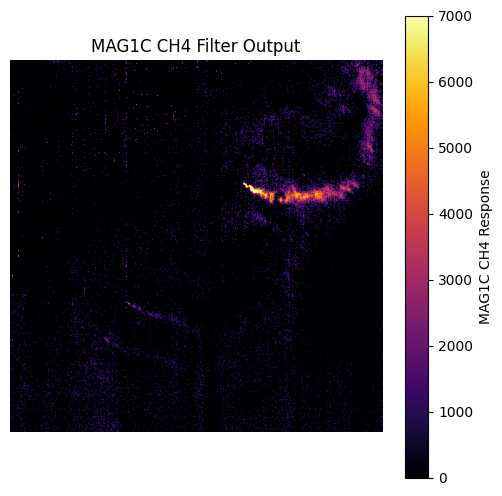


=== COMPARISON RESULTS ===
PyTorch result shape: torch.Size([512, 512])
NumPy result shape: (512, 512)
PyTorch range: [-9999.000000, 44269.992167]
NumPy range: [-9999.000000, 44269.991624]
Max absolute difference: 0.007925
Mean absolute difference: 0.000005
RMSE: 0.000052
Non-matching elements: 65/262144 (0.0248%)
✓ SUCCESS: NumPy and PyTorch outputs match within tolerance!

Non-censored regions only:
Max diff in non-censored: 7.925082e-03
Mean diff in non-censored: 5.449917e-06


In [3]:
import numpy as np
from typing import Tuple, Optional
import torch

NODATA = -9999

def get_censor_mask(x: np.ndarray) -> np.ndarray:
    """Determines the regions of the image that are censored. This assumes that an
    entire 'bar'/sample-direction (in un-geocorrected data) is censored together.

    :param x: Radiance image data to analyze for censored regions.
    :return: Boolean 1D ndarray (corresponding to column/flight direction) with True where censoring is detected.
    """
    is_censored = np.diff(x, axis=0) == 0
    is_censored = np.all(is_censored, axis=(1, 2))
    is_censored = np.logical_or(
        np.logical_or(
            np.concatenate(([0, 0], is_censored[:-1])),
            np.concatenate((is_censored[1:], [0, 0])),
        ),
        np.logical_or(
            np.concatenate(([1], is_censored)), np.concatenate((is_censored, [1]))
        ),
    )
    # Also skip regions that are marked as No Data, value -9999
    is_censored = np.logical_or(
        is_censored, np.any(x == NODATA, axis=(1, 2))
    )
    return is_censored

def compute_sampled_filter_numpy(rdn_data, sat_mask, spec, indices):
    print(f"numpy - rdn_data shape: {rdn_data.shape}, spec shape: {spec.shape}")
    print(f"numpy - rdn_data dtype: {rdn_data.dtype}, spec dtype: {spec.dtype}")
    
    rdn_data_sample = rdn_data[:, indices, :]
    sat_mask_sample = sat_mask[:, indices] if sat_mask is not None else None
    
    mu, Cit, normalizer = acrwl1mf_numpy(
        x=rdn_data_sample,
        template=spec,
        num_iter=30,
        albedo_override=False,
        zero_override=False,
        sparse_override=False,
        covariance_update_scaling=1.0,
        alpha=0.0,
        mask=np.logical_not(sat_mask_sample) if sat_mask_sample is not None else None,
        sample=True,
    )
    
    mf_out, albedo_out = acrwl1mf_compact_numpy(
        x=rdn_data,
        normalizer=normalizer,
        num_iter=3,
        albedo_override=False,
        zero_override=False,
        sparse_override=False,
        mu=mu,
        Cit=Cit,
    )
    return mf_out, albedo_out

def acrwl1mf_numpy(
    x: np.ndarray,
    template: np.ndarray,
    num_iter: int,
    albedo_override: bool,
    zero_override: bool,
    sparse_override: bool,
    covariance_update_scaling: float,
    alpha: float,
    mask: Optional[np.ndarray],
    sample: bool,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Calculate the albedo-corrected reweighted-L1 matched filter on radiance data using NumPy."""
    
    dtype = x.dtype
    N = x.shape[1]  # number of samples
    
    if mask is None:
        mask = np.ones(x.shape, dtype=bool)
    mask = np.squeeze(mask, 0)
    
    regularizer = np.zeros((x.shape[0], x.shape[1], 1), dtype=dtype)
    modx = x[:, mask]
    
    scaling = np.array(1e5, dtype=dtype)
    epsilon = np.array(1e-9, dtype=dtype)
    covariance_update_scaling = np.array(-covariance_update_scaling, dtype=dtype)
    alpha = np.array(alpha, dtype=dtype)
    
    # Initialize with normal robust matched filter
    mu = np.mean(modx, axis=1, keepdims=True)  # [batch x 1 x spectrum]
    
    if albedo_override:
        R = np.ones((x.shape[0], N, 1), dtype=dtype)
    else:
        # [b x p x s] * [b x s x 1] = [b x p x 1]
        numerator = np.matmul(x, np.transpose(mu, (0, 2, 1)))
        # [b x 1 x s] * [b x s x 1] = [b x 1 x 1]
        denominator = np.matmul(mu, np.transpose(mu, (0, 2, 1)))
        R = np.divide(numerator, denominator)
    
    target = template * mu  # [1 x 1 x s] * [b x 1 x s] = [b x 1 x s]
    xmean = modx - mu
    
    # [b x s x p] * [b x p x s] = [b x s x s]
    C = np.matmul(np.transpose(xmean, (0, 2, 1)), xmean) / N
    
    # C = (1-alpha) * S + alpha * diag(S)
    diag_C = np.zeros_like(C)
    for i in range(C.shape[0]):
        diag_C[i] = np.diag(np.diag(C[i]))
    C = (1 - alpha) * C + alpha * diag_C
    
    # Solve using Cholesky decomposition
    Cit = np.zeros_like(np.transpose(target, (0, 2, 1)))
    for i in range(C.shape[0]):
        L = np.linalg.cholesky(C[i])
        # Solve L L^T Cit = target^T
        y = np.linalg.solve(L, np.transpose(target, (0, 2, 1))[i])
        Cit[i] = np.linalg.solve(L.T, y)
    
    normalizer = np.matmul(target, Cit)  # [b x 1 x s] * [b x s x 1] = [b x 1 x 1]
    
    # [b x p x s] * [b x s x 1] = [b x p x 1]
    numerator_mf = np.matmul(x - mu, Cit)
    denominator_mf = R * normalizer
    mf = np.divide(numerator_mf, denominator_mf)
    
    if not zero_override:
        mf = np.maximum(mf, 0)  # ReLU equivalent
    
    # Reweighted L1 Algorithm
    for i in range(num_iter):
        # Calculate new regularizer weights
        if not sparse_override:
            regularizer = np.reciprocal(R * mf + epsilon)
        
        # Re-calculate statistics
        modx = x[:, mask] + covariance_update_scaling * (R[:, mask] * mf[:, mask] * target)
        mu = np.mean(modx, axis=1, keepdims=True)
        target = template * mu
        xmean = modx - mu
        
        C = np.matmul(np.transpose(xmean, (0, 2, 1)), xmean) / N
        
        # Apply diagonal scaling
        for j in range(C.shape[0]):
            diag_C[j] = np.diag(np.diag(C[j]))
        C = (1 - alpha) * C + alpha * diag_C
        
        # Update Cit using Cholesky
        for j in range(C.shape[0]):
            L = np.linalg.cholesky(C[j])
            y = np.linalg.solve(L, np.transpose(target, (0, 2, 1))[j])
            Cit[j] = np.linalg.solve(L.T, y)
        
        # Compute matched filter with regularization
        normalizer = np.matmul(target, Cit)
        if np.any(normalizer < 1):
            normalizer = np.clip(normalizer, 1, None)
            
        if num_iter == i + 1 and sample:
            return mu, Cit, normalizer
            
        numerator_mf = np.matmul(x - mu, Cit) - regularizer
        denominator_mf = R * normalizer
        mf = np.divide(numerator_mf, denominator_mf)
        
        if not zero_override:
            mf = np.maximum(mf, 0)
    
    mf = mf * scaling
    return mf, R, normalizer

def acrwl1mf_compact_numpy(
    x: np.ndarray,
    normalizer: np.ndarray,
    num_iter: int,
    albedo_override: bool,
    zero_override: bool,
    sparse_override: bool,
    mu: np.ndarray,
    Cit: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """Calculate the albedo-corrected reweighted-L1 matched filter on radiance data using NumPy."""
    
    dtype = x.dtype
    N = x.shape[1]  # number of samples
    
    regularizer = np.zeros((x.shape[0], x.shape[1], 1), dtype=dtype)
    scaling = np.array(1e5, dtype=dtype)
    epsilon = np.array(1e-9, dtype=dtype)
    
    # Initialize with normal robust matched filter
    if albedo_override:
        R = np.ones((x.shape[0], N, 1), dtype=dtype)
    else:
        numerator = np.matmul(x, np.transpose(mu, (0, 2, 1)))
        denominator = np.matmul(mu, np.transpose(mu, (0, 2, 1)))
        R = np.divide(numerator, denominator)
    
    if np.any(normalizer < 1):
        normalizer = np.clip(normalizer, 1, None)
    
    numerator_mf = np.matmul(x - mu, Cit)
    denominator_mf = R * normalizer
    mf_0 = np.divide(numerator_mf, denominator_mf)
    
    if not zero_override:
        mf_0 = np.maximum(mf_0, 0)
    
    mf = mf_0.copy()
    
    # Reweighted L1 Algorithm
    for i in range(num_iter):
        # Calculate new regularizer weights
        if not sparse_override:
            regularizer = np.reciprocal(R * mf + epsilon)
        
        mf = mf_0 - np.divide(regularizer, R * normalizer)
        
        if not zero_override:
            mf = np.maximum(mf, 0)
    
    mf = mf * scaling
    return mf, R

def get_mask_bad_bands(wave: np.ndarray) -> np.ndarray:
    """Calculates a mask of the wavelengths to keep based on water vapor absorption features."""
    keep_mask = ~(
        np.logical_or(
            np.logical_or(wave < 400, wave > 2485),
            np.logical_or(
                np.logical_and(wave > 1350, wave < 1420),
                np.logical_and(wave > 1800, wave < 1945),
            ),
        )
    )
    return keep_mask

import numpy as np
import torch

# Use the NumPy implementation
sample_size = int(0.01*(512*512))
step_size = 512*512 // sample_size
indices = np.arange(0, 512*512, step_size)[:sample_size]
wavelengths = np.load("mag1c_centers.npy")
keep_bands_indices = get_mask_bad_bands(wavelengths)
print(f"Image shape: {img.shape}")

censor_mask = get_censor_mask(img.astype(np.float64))
print(f"Censor mask shape: {censor_mask.shape}")

# Create output array using NumPy
mag1c_sas_numpy = np.zeros((1, 512*512, 1), dtype=np.float64)
mag1c_sas_numpy[:, censor_mask, :] = NODATA

# Use NumPy implementation for the computation
mag1c_sas_numpy[:, ~censor_mask, :], _ = compute_sampled_filter_numpy(
    rdn_data=img[~censor_mask, :, :].reshape(1, -1, 50).astype(np.float64)[:, :, keep_bands_indices],
    sat_mask=np.zeros((1, 262144), dtype=bool),
    spec=np.load("mag1c_spectrum.npy")[keep_bands_indices],
    indices=indices
)

print(f"NumPy result shape: {mag1c_sas_numpy.shape}")

# Reshape to 2D image
ch4_img_numpy = mag1c_sas_numpy.reshape((512, 512))

# Create visualization
mag1c_sas_vis_numpy = np.clip(ch4_img_numpy, 0, 7000)

# Visualize NumPy results
if ch4_img_numpy is not None:
    print("Visualizing NumPy results:")
    visualize_results(mag1c_sas_vis_numpy)

# Compare with original PyTorch output (ch4_img_new)
print("\n=== COMPARISON RESULTS ===")
print(f"PyTorch result shape: {ch4_img_new.shape if 'ch4_img_new' in locals() else 'Not available'}")
print(f"NumPy result shape: {ch4_img_numpy.shape}")

# Convert PyTorch tensor to NumPy array for comparison
if torch.is_tensor(ch4_img_new):
    ch4_img_new_np = ch4_img_new.detach().numpy()
else:
    ch4_img_new_np = ch4_img_new

# Calculate statistics using NumPy arrays
diff = np.abs(ch4_img_new_np - ch4_img_numpy)

print(f"PyTorch range: [{ch4_img_new_np.min():.6f}, {ch4_img_new_np.max():.6f}]")
print(f"NumPy range: [{ch4_img_numpy.min():.6f}, {ch4_img_numpy.max():.6f}]")
print(f"Max absolute difference: {diff.max():.6f}")
print(f"Mean absolute difference: {diff.mean():.6f}")
print(f"RMSE: {np.sqrt(np.mean(diff**2)):.6f}")

# Count non-matching elements
non_matching = np.sum(diff > 1e-3)
total_elements = ch4_img_new_np.size
print(f"Non-matching elements: {non_matching}/{total_elements} ({100*non_matching/total_elements:.4f}%)")

# Test with the same tolerance as original
try:
    np.testing.assert_allclose(ch4_img_new_np, ch4_img_numpy, rtol=1e-1, atol=1e-3)
    print("✓ SUCCESS: NumPy and PyTorch outputs match within tolerance!")
except AssertionError as e:
    print("✗ FAILED: NumPy and PyTorch outputs differ!")
    print(f"Error: {e}")
    
# Additional comparison for non-censored regions only
non_censored_mask = ~censor_mask.reshape(512, 512)
if np.any(non_censored_mask):
    torch_non_censored = ch4_img_new_np[non_censored_mask]
    numpy_non_censored = ch4_img_numpy[non_censored_mask]
    non_censored_diff = np.abs(torch_non_censored - numpy_non_censored)
    print(f"\nNon-censored regions only:")
    print(f"Max diff in non-censored: {non_censored_diff.max():.6e}")
    print(f"Mean diff in non-censored: {non_censored_diff.mean():.6e}")

# Mag1c (NumPy, cleansed)
In this code the Numpy version is cleaned of unnecessary operation and tested that they provide the same results as the original NumPy.

Image shape: (262144, 1, 50)
Censor mask shape: (262144,)
NumPy result shape: (1, 262144, 1)
Visualizing NumPy results:
Visualizing MAG1C CH4 output...


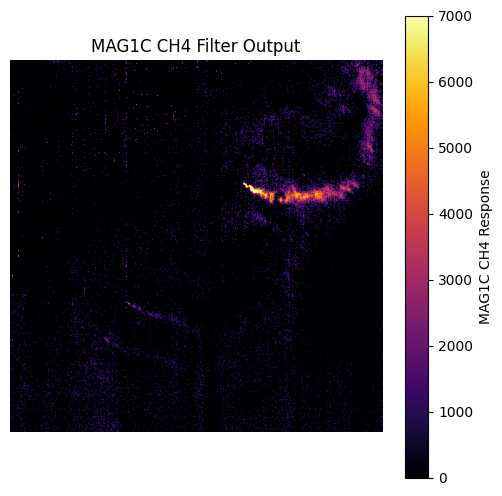


=== COMPARISON RESULTS ===
PyTorch result shape: torch.Size([512, 512])
NumPy result shape: (512, 512)
PyTorch range: [-9999.000000, 44269.992167]
NumPy range: [-9999.000000, 44269.991624]
Max absolute difference: 0.007925
Mean absolute difference: 0.000005
RMSE: 0.000052
Non-matching elements: 65/262144 (0.0248%)
✓ SUCCESS: NumPy and PyTorch outputs match within tolerance!

Non-censored regions only:
Max diff in non-censored: 7.925082e-03
Mean diff in non-censored: 5.449917e-06


In [10]:
import numpy as np
from typing import Tuple, Optional
import torch

NODATA = -9999

def get_censor_mask(x: np.ndarray) -> np.ndarray:
    """Determines the regions of the image that are censored. This assumes that an
    entire 'bar'/sample-direction (in un-geocorrected data) is censored together.

    :param x: Radiance image data to analyze for censored regions.
    :return: Boolean 1D ndarray (corresponding to column/flight direction) with True where censoring is detected.
    """
    is_censored = np.diff(x, axis=0) == 0
    is_censored = np.all(is_censored, axis=(1, 2))
    is_censored = np.logical_or(
        np.logical_or(
            np.concatenate(([0, 0], is_censored[:-1])),
            np.concatenate((is_censored[1:], [0, 0])),
        ),
        np.logical_or(
            np.concatenate(([1], is_censored)), np.concatenate((is_censored, [1]))
        ),
    )
    # Also skip regions that are marked as No Data, value -9999
    is_censored = np.logical_or(
        is_censored, np.any(x == NODATA, axis=(1, 2))
    )
    return is_censored

def compute_sampled_filter_numpy_cleaned(rdn_data, spec, indices):
    rdn_data_sample = rdn_data[:, indices, :]
    mu, Cit, normalizer = acrwl1mf_numpy_cleaned(
        x=rdn_data_sample,
        template=spec,
        num_iter=30,
        sample=True,
    )
    
    mf_out, albedo_out = acrwl1mf_compact_numpy_cleaned(
        x=rdn_data,
        normalizer=normalizer,
        num_iter=3,
        mu=mu,
        Cit=Cit,
    )
    return mf_out, albedo_out

def acrwl1mf_numpy_cleaned(
    x: np.ndarray,
    template: np.ndarray,
    num_iter: int,
    sample: bool,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Calculate the albedo-corrected reweighted-L1 matched filter on radiance data using NumPy."""
    dtype = x.dtype
    N = x.shape[1]  # number of samples
    regularizer = np.zeros((x.shape[0], x.shape[1], 1), dtype=dtype)
    modx = x
    
    scaling = np.array(1e5, dtype=dtype)
    epsilon = np.array(1e-9, dtype=dtype)
    
    # Initialize with normal robust matched filter
    mu = np.mean(modx, axis=1, keepdims=True)  # [batch x 1 x spectrum]
    
    # [b x p x s] * [b x s x 1] = [b x p x 1]
    numerator = np.matmul(x, np.transpose(mu, (0, 2, 1)))
    # [b x 1 x s] * [b x s x 1] = [b x 1 x 1]
    denominator = np.matmul(mu, np.transpose(mu, (0, 2, 1)))
    R = np.divide(numerator, denominator)
    
    target = template * mu  # [1 x 1 x s] * [b x 1 x s] = [b x 1 x s]
    xmean = modx - mu
    
    # [b x s x p] * [b x p x s] = [b x s x s]
    C = np.matmul(np.transpose(xmean, (0, 2, 1)), xmean) / N

    
    # Solve using Cholesky decomposition
    Cit = np.zeros_like(np.transpose(target, (0, 2, 1)))
    for i in range(C.shape[0]):
        L = np.linalg.cholesky(C[i])
        # Solve L L^T Cit = target^T
        y = np.linalg.solve(L, np.transpose(target, (0, 2, 1))[i])
        Cit[i] = np.linalg.solve(L.T, y)
    
    normalizer = np.matmul(target, Cit)  # [b x 1 x s] * [b x s x 1] = [b x 1 x 1]
    
    # [b x p x s] * [b x s x 1] = [b x p x 1]
    numerator_mf = np.matmul(x - mu, Cit)
    denominator_mf = R * normalizer
    mf = np.divide(numerator_mf, denominator_mf)
    
    mf = np.maximum(mf, 0)  # ReLU equivalent
    
    # Reweighted L1 Algorithm
    for i in range(num_iter):
        # Calculate new regularizer weights
        regularizer = np.reciprocal(R * mf + epsilon)
        
        # Re-calculate statistics
        modx = x - (R * mf * target)
        mu = np.mean(modx, axis=1, keepdims=True)
        target = template * mu
        xmean = modx - mu
        
        C = np.matmul(np.transpose(xmean, (0, 2, 1)), xmean) / N
    
        
        # Update Cit using Cholesky
        for j in range(C.shape[0]):
            L = np.linalg.cholesky(C[j])
            y = np.linalg.solve(L, np.transpose(target, (0, 2, 1))[j])
            Cit[j] = np.linalg.solve(L.T, y)
        
        # Compute matched filter with regularization
        normalizer = np.matmul(target, Cit)
        if np.any(normalizer < 1):
            normalizer = np.clip(normalizer, 1, None)
            
        if num_iter == i + 1 and sample:
            return mu, Cit, normalizer
            
        numerator_mf = np.matmul(x - mu, Cit) - regularizer
        denominator_mf = R * normalizer
        mf = np.divide(numerator_mf, denominator_mf)
        
        mf = np.maximum(mf, 0)
    
    mf = mf * scaling
    return mf, R, normalizer

def acrwl1mf_compact_numpy_cleaned(
    x: np.ndarray,
    normalizer: np.ndarray,
    num_iter: int,
    mu: np.ndarray,
    Cit: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """Calculate the albedo-corrected reweighted-L1 matched filter on radiance data using NumPy."""
    
    dtype = x.dtype
    
    regularizer = np.zeros((x.shape[0], x.shape[1], 1), dtype=dtype)
    scaling = np.array(1e5, dtype=dtype)
    epsilon = np.array(1e-9, dtype=dtype)
    
    # Initialize with normal robust matched filter
    numerator = np.matmul(x, np.transpose(mu, (0, 2, 1)))
    denominator = np.matmul(mu, np.transpose(mu, (0, 2, 1)))
    R = np.divide(numerator, denominator)
    
    if np.any(normalizer < 1):
        normalizer = np.clip(normalizer, 1, None)
    
    numerator_mf = np.matmul(x - mu, Cit)
    denominator_mf = R * normalizer
    mf_0 = np.divide(numerator_mf, denominator_mf)
    
    mf_0 = np.maximum(mf_0, 0)
    
    mf = mf_0.copy()
    
    # Reweighted L1 Algorithm
    for i in range(num_iter):
        # Calculate new regularizer weights
        regularizer = np.reciprocal(R * mf + epsilon)
        
        mf = mf_0 - np.divide(regularizer, R * normalizer)
        
        mf = np.maximum(mf, 0)
    
    mf = mf * scaling
    return mf, R

def get_mask_bad_bands(wave: np.ndarray) -> np.ndarray:
    """Calculates a mask of the wavelengths to keep based on water vapor absorption features."""
    keep_mask = ~(
        np.logical_or(
            np.logical_or(wave < 400, wave > 2485),
            np.logical_or(
                np.logical_and(wave > 1350, wave < 1420),
                np.logical_and(wave > 1800, wave < 1945),
            ),
        )
    )
    return keep_mask

import numpy as np
import torch

# Use the NumPy implementation
sample_size = int(0.01*(512*512))
step_size = 512*512 // sample_size
indices = np.arange(0, 512*512, step_size)[:sample_size]
wavelengths = np.load("mag1c_centers.npy")
keep_bands_indices = get_mask_bad_bands(wavelengths)
print(f"Image shape: {img.shape}")

censor_mask = get_censor_mask(img.astype(np.float64))
print(f"Censor mask shape: {censor_mask.shape}")

# Create output array using NumPy
mag1c_sas_numpy = np.zeros((1, 512*512, 1), dtype=np.float64)
mag1c_sas_numpy[:, censor_mask, :] = NODATA

# Use NumPy implementation for the computation
mag1c_sas_numpy[:, ~censor_mask, :], _ = compute_sampled_filter_numpy_cleaned(
    rdn_data=img[~censor_mask, :, :].reshape(1, -1, 50).astype(np.float64)[:, :, keep_bands_indices],
    spec=np.load("mag1c_spectrum.npy")[keep_bands_indices],
    indices=indices
)

print(f"NumPy result shape: {mag1c_sas_numpy.shape}")

# Reshape to 2D image
ch4_img_numpy = mag1c_sas_numpy.reshape((512, 512))

# Create visualization
mag1c_sas_vis_numpy = np.clip(ch4_img_numpy, 0, 7000)

# Visualize NumPy results
if ch4_img_numpy is not None:
    print("Visualizing NumPy results:")
    visualize_results(mag1c_sas_vis_numpy)

# Compare with original PyTorch output (ch4_img_new)
print("\n=== COMPARISON RESULTS ===")
print(f"PyTorch result shape: {ch4_img_new.shape if 'ch4_img_new' in locals() else 'Not available'}")
print(f"NumPy result shape: {ch4_img_numpy.shape}")

# Convert PyTorch tensor to NumPy array for comparison
if torch.is_tensor(ch4_img_new):
    ch4_img_new_np = ch4_img_new.detach().numpy()
else:
    ch4_img_new_np = ch4_img_new

# Calculate statistics using NumPy arrays
diff = np.abs(ch4_img_new_np - ch4_img_numpy)

print(f"PyTorch range: [{ch4_img_new_np.min():.6f}, {ch4_img_new_np.max():.6f}]")
print(f"NumPy range: [{ch4_img_numpy.min():.6f}, {ch4_img_numpy.max():.6f}]")
print(f"Max absolute difference: {diff.max():.6f}")
print(f"Mean absolute difference: {diff.mean():.6f}")
print(f"RMSE: {np.sqrt(np.mean(diff**2)):.6f}")

# Count non-matching elements
non_matching = np.sum(diff > 1e-3)
total_elements = ch4_img_new_np.size
print(f"Non-matching elements: {non_matching}/{total_elements} ({100*non_matching/total_elements:.4f}%)")

# Test with the same tolerance as original
try:
    np.testing.assert_allclose(ch4_img_new_np, ch4_img_numpy, rtol=1e-1, atol=1e-3)
    print("✓ SUCCESS: NumPy and PyTorch outputs match within tolerance!")
except AssertionError as e:
    print("✗ FAILED: NumPy and PyTorch outputs differ!")
    print(f"Error: {e}")
    
# Additional comparison for non-censored regions only
non_censored_mask = ~censor_mask.reshape(512, 512)
if np.any(non_censored_mask):
    torch_non_censored = ch4_img_new_np[non_censored_mask]
    numpy_non_censored = ch4_img_numpy[non_censored_mask]
    non_censored_diff = np.abs(torch_non_censored - numpy_non_censored)
    print(f"\nNon-censored regions only:")
    print(f"Max diff in non-censored: {non_censored_diff.max():.6e}")
    print(f"Mean diff in non-censored: {non_censored_diff.mean():.6e}")